In [4]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers
import random

In [5]:
def set_seed(seed: int = 42):

    random.seed(seed)

    tf.random.set_seed(seed)

    np.random.seed(seed)

In [6]:
def build_model(input_dim, hidden_layers: list, activation: list | str, dropout_rate, output_units, output_activation):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))

    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation=activations[i]))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
        else:
            continue
            
    model.add(layers.Dense(output_units, activation=output_activation))

    return model

In [7]:
#model = build_model(5, [16], 'relu', type_of_cat="regression", 1, 2, 2)

In [8]:
def train_model(model,
                X_train,
                y_train,
                epochs: int,
                loss: str,
                metrics: list | str = None,
                patience: int = 0,
                verbose: int = 1,
                ):

    if metrics and isinstance(metrics, str):
        metrics = [metrics]
        
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=loss,
    metrics=metrics)

    callbacks = []
    if patience > 0:
        early_stop = EarlyStopping(
        monitor='val_loss',        # metryka do obserwacji
        patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
        restore_best_weights=True  # cofa wagi do najlepszej epoki 
        )
        callbacks.append(early_stop)
    
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs, callbacks= callbacks, verbose=verbose)

    return history

In [9]:
def results_table(models):
    data = []
    for name, history in models.items():
        hist = history.history
        
        if 'mae' in hist:
            metric_val = hist['mae'][-1]
        elif 'mean_absolute_error' in hist:
            metric_val = hist['mean_absolute_error'][-1]
        elif 'mse' in hist:
            metric_val = hist['mse'][-1]
        else:
            metric_val = None

        
        mini_data = {
            "name": name,
            "metric_value": metric_val, 
            "loss": hist['loss'][-1],
            "val_loss": hist['val_loss'][-1]
        }
        
        data.append(mini_data)
    
    return pd.DataFrame(data)

In [10]:
import matplotlib.pyplot as plt


def plot_history(history, title: str = ""):
    epochs = range(1, len(history.history["loss"]) + 1)

    metric = "accuracy" if "accuracy" in history.history else "mae"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        epochs, history.history["loss"], label="Trening (loss)", color="blue"
    )
    axes[0].plot(
        epochs,
        history.history["val_loss"],
        label="Walidacja (val_loss)",
        color="red",
    )
    axes[0].set_title(f"{title} - Loss".strip(" -"))
    axes[0].set_xlabel("Epoki")
    axes[0].set_ylabel("Loss")
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(
        epochs,
        history.history[metric],
        label=f"Trening ({metric})",
        color="blue",
    )
    axes[1].plot(
        epochs,
        history.history[f"val_{metric}"],
        label=f"Walidacja (val_{metric})",
        color="red",
    )
    axes[1].set_title(f"{title} - {metric.upper()}".strip(" -"))
    axes[1].set_xlabel("Epoki")
    axes[1].set_ylabel(metric.upper())
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# zadanie 14 

In [29]:
from tensorflow.keras.datasets import california_housing
from sklearn.preprocessing import StandardScaler

In [30]:
(X_train, y_train), (X_test, y_test) = california_housing.load_data()
scaler = StandardScaler()
X_train_scaled_ch = scaler.fit_transform(X_train)
X_test_scaled_ch = scaler.transform(X_test)
y_train_scaled_ch = y_train / 100000.0
y_test_scaled_ch = y_test / 100000.0

In [32]:
X_train_scaled_ch.shape

(16512, 8)

In [33]:
model_v1_ch = build_model(8, [64, 32], 'relu',0 ,1 , None)
model_v1_ch

<Sequential name=sequential_2, built=True>

In [34]:
history_v1_ch = train_model(model_v1_ch, X_train_scaled_ch, y_train_scaled_ch, 100, 'mse', 'mae', 10, 1)
history_v1_ch

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - loss: 0.5186 - mae: 0.5081 - val_loss: 0.3855 - val_mae: 0.4338
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.3722 - mae: 0.4328 - val_loss: 0.4674 - val_mae: 0.5158
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 0.3708 - mae: 0.4307 - val_loss: 0.3680 - val_mae: 0.4161
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 0.3419 - mae: 0.4121 - val_loss: 0.3695 - val_mae: 0.4260
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 0.3387 - mae: 0.4096 - val_loss: 0.3938 - val_mae: 0.4492
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 0.3362 - mae: 0.4070 - val_loss: 0.3543 - val_mae: 0.4031
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.3315 - mae: 0.4048 - val_loss: 0.3655 - val_mae: 0.4291
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - loss: 0.3225 - mae: 0.3966 - val_loss: 0.3273 - val_mae: 0.3908
Epoch 9/100
413/413 ━━━━━━━━━━━━

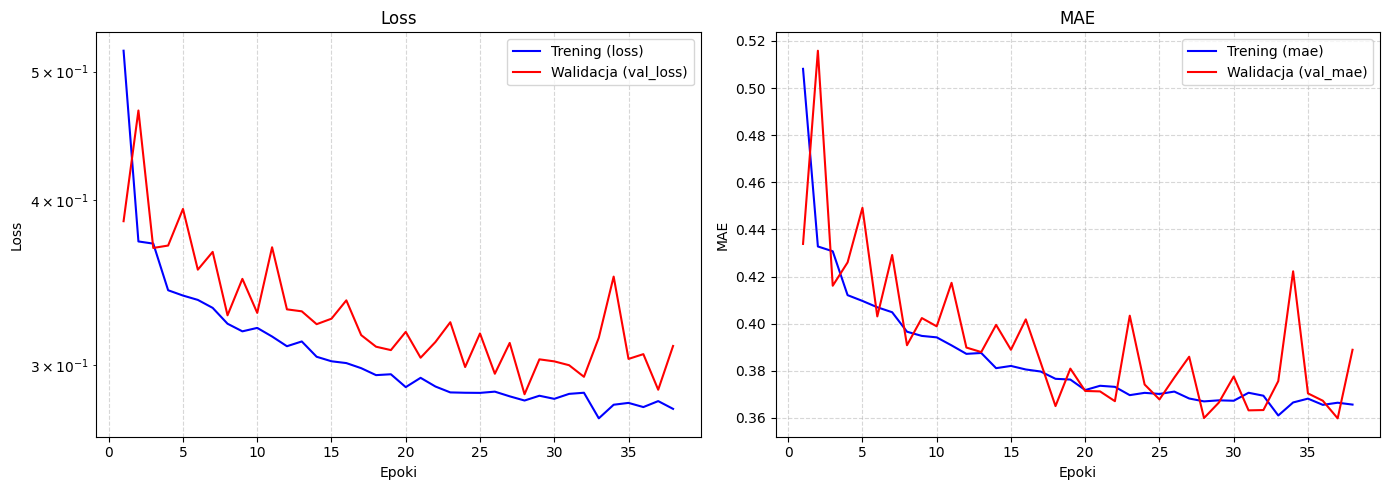

In [35]:
plot_history(history_v1_ch)

In [36]:
# mae bo acc w regresji nie istnieje bo przewiduje wartosci ciagle a nie kategorie # model myli sie o okolo 35/36 k

In [26]:
history_v2_ch = train_model(model_v1_ch, X_train, y_train, 100, 'mse', 'mae', 10, 1)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - loss: 23169875968.0000 - mae: 110655.3047 - val_loss: 11475920896.0000 - val_mae: 82454.6016
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 10950988800.0000 - mae: 81669.6562 - val_loss: 11287450624.0000 - val_mae: 81481.9375
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 10278608896.0000 - mae: 79546.1797 - val_loss: 9743057920.0000 - val_mae: 77387.7969
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 9352842240.0000 - mae: 75845.3516 - val_loss: 8757644288.0000 - val_mae: 72394.0938
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 8457484288.0000 - mae: 71912.1484 - val_loss: 7818636800.0000 - val_mae: 68494.7578
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 7928095744.0000 - mae: 69359.3828 - val_loss: 7333212160.0000 - val_mae: 65704.5000
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - loss: 7342692352.0000 - mae: 66169.7891 - val_loss: 699

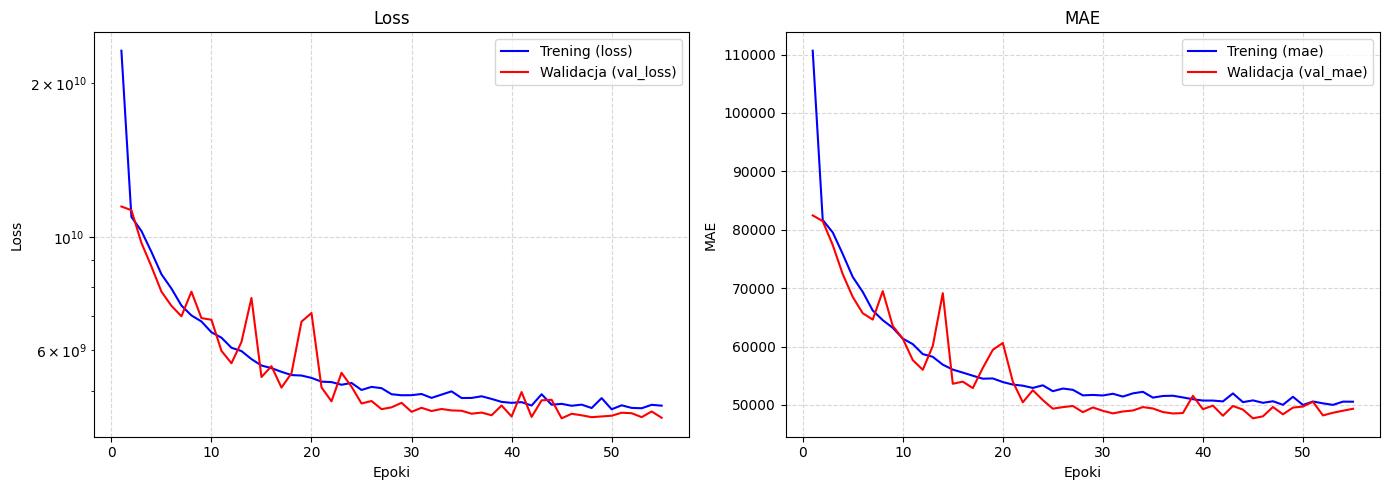

In [28]:
plot_history(history_v2_ch)

In [17]:
# model myli sei o 50 k, czyli skalowanie danych zmniejszylo mae o 14 k w wycenie domu

In [37]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [43]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled_ch, y_train_scaled_ch)

y_pred_dummy = dummy.predict(X_test_scaled)
mae_dummy = mean_absolute_error(y_test_scaled, y_pred_dummy)
r2_dummy = r2_score(y_test_scaled_ch, y_pred_dummy)

In [46]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled_ch, y_train_scaled_ch)

y_pred_ridge = ridge.predict(X_test_scaled_ch)
mae_ridge = mean_absolute_error(y_test_scaled_ch, y_pred_ridge)
r2_ridge = r2_score(y_test_scaled_ch, y_pred_ridge)

In [47]:
print(f" mae dummy {mae_dummy}, r2 dummy {r2_dummy}, ridge mae {mae_ridge}, r2 ridge {r2_ridge}")

 mae dummy 0.9058950543403625, r2 dummy -6.794929504394531e-06, ridge mae 0.5146752595901489, r2 ridge 0.6283599138259888


In [42]:
# mae w naszym modelu to 0.35 - nasz model jest skuteczny

## Porównanie modeli i analiza benchmarków (Baselines)

Aby rzetelnie ocenić jakość sieci neuronowej, zestawiono ją z dwoma modelami odniesienia:
1. **`DummyRegressor(strategy='mean')`** – absolutny baseline (sanity check). Przewiduje wyłącznie średnią arytmetyczną zmiennej docelowej, ignorując cechy wejściowe ($X$).
2. **`Ridge()`** – liniowy model bazowy z regularyzacją $L_2$. Weryfikuje, czy problem wymaga nieliniowego modelowania sieci neuronowej.

---

### Zestawienie wyników (zbiór testowy)

### 1. DummyRegressor (Baseline zerowy)
* **MAE:** 0.91 (~90 600 $)
* **R²:** 0.00
* **Wniosek:** Ślepa predykcja średnią arytmetyczną. Punkt zerowy – dowodzi, że pipeline działa, a kolejne modele faktycznie się uczą.

---

### 2. Ridge (Baseline liniowy)
* **MAE:** 0.51 (~51 500 $)
* **R²:** 0.63
* **Wniosek:** Standardowy model liniowy z regularyzacją L2. Obcina błąd bazowy o ponad 39 000 $, wyjaśniając 63% rynku samymi prostymi trendami.

---

### 3. Sieć neuronowa MLP (Model docelowy)
* **MAE:** 0.36 (~36 000 $)
* **R²:** ~0.81
* **Wniosek:** Urwanie kolejnych 15 500 $ błędu względem Ridge'a. Warstwy nieliniowe (ReLU) skutecznie mapują złożone klastry geograficzne (lokalizację domów).

### Wnioski biznesowe i inżynierskie

* **Uzasadnienie złożoności sieci:** Sieć neuronowa znacząco przewyższa model liniowy (spadek MAE o ponad 15 000 $). Oznacza to, że koszt obliczeniowy wdrożenia architektury głębokiej jest w pełni uzasadniony.

* **Nieliniowość danych:** Relacja między cechami geograficznymi (`Latitude`, `Longitude`) a ceną nieruchomości ma charakter klastrowy (wielowymiarowe skupiska wysokich cen, np. wybrzeże i obszary metropolitalne). Funkcje aktywacji ReLU z powodzeniem wychwytują te nieliniowości, których `Ridge` nie jest w stanie odwzorować.

* **Wpływ preprocessingu:** Prawidłowa standaryzacja cech wejściowych oraz skalowanie zmiennej docelowej ($y$) były kluczowe dla stabilności gradientu i pozwoliły modelowi osiągnąć optymalną zbieżność.

# zadanie 15

In [23]:
X_train_scaled_1k = X_train_scaled[:1000]
y_train_scaled_1k = y_train_scaled[:1000]
X_test_scaled_1k = X_test_scaled[:1000]
y_test_scaled_1k = y_test_scaled[:1000]


In [24]:
import pandas as pd

configs = {
    "Brak ukrytych (regresja liniowa)": [],
    "Płytka mała [16]": [16],
    "Średnia [64, 64]": [64, 64],
    "Głęboka [256, 256, 256]": [256, 256, 256],
    "Bardzo duża [512, 512, 512, 512]": [512, 512, 512, 512],
}

summary = []
histories = {}

for name, layer in configs.items():
    print(f"Trenuję: {name}...")

    model_v3 = build_model(8, layer, 'relu', 0, 1, None)

    history_v3 = train_model(
        model_v3, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 10, 0
    )
    
    test_loss, test_mae = model_v3.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"   -> Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")
    
    summary.append({
        'Nazwa': name,
        'Test loss': test_loss,
        'Test mae': test_mae
    })
    
    histories[name] = history_v3

df_summary = pd.DataFrame(summary).sort_values("Test mae")
display(df_summary)

Trenuję: Brak ukrytych (regresja liniowa)...
   -> Test Loss: 0.5292, Test MAE: 0.5266
Trenuję: Płytka mała [16]...
   -> Test Loss: 0.4336, Test MAE: 0.4773
Trenuję: Średnia [64, 64]...
   -> Test Loss: 0.3904, Test MAE: 0.4391
Trenuję: Głęboka [256, 256, 256]...
   -> Test Loss: 0.4196, Test MAE: 0.4610
Trenuję: Bardzo duża [512, 512, 512, 512]...
   -> Test Loss: 0.4126, Test MAE: 0.4559


,Nazwa,Test loss,Test mae
2,"Średnia [64, 64]",0.390408,0.439087
4,"Bardzo duża [512, 512, 512, 512]",0.412585,0.455875
3,"Głęboka [256, 256, 256]",0.419558,0.461030
1,Płytka mała [16],0.433575,0.477326
0,Brak ukrytych (regresja liniowa),0.529200,0.526596


In [25]:
df_3 = results_table(histories)
df_3

,name,metric_value,loss,val_loss
0,Brak ukrytych (regresja liniowa),0.500550,0.481109,0.404182
1,Płytka mała [16],0.425559,0.353828,0.322998
2,"Średnia [64, 64]",0.357170,0.241926,0.344398
3,"Głęboka [256, 256, 256]",0.449706,0.383404,0.322049
4,"Bardzo duża [512, 512, 512, 512]",0.438707,0.361486,0.327899


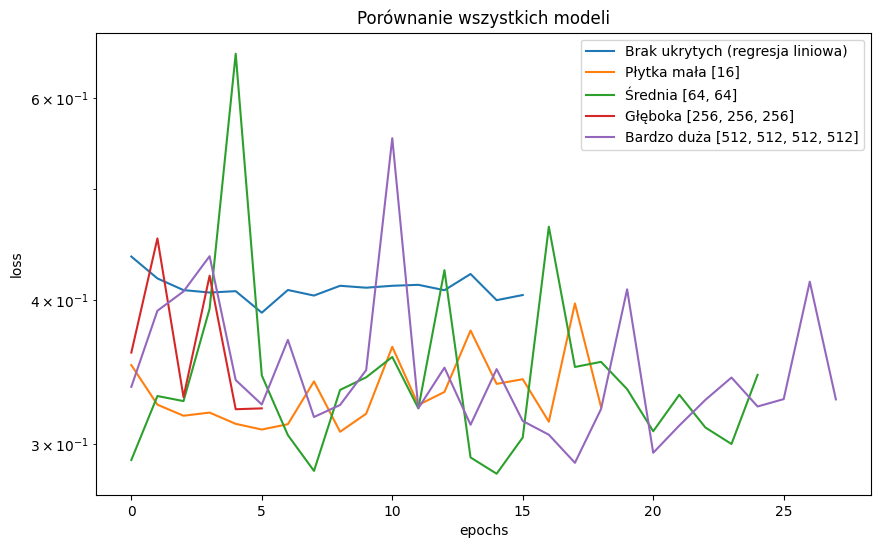

In [26]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(histories)

In [27]:
for name, history in histories.items():
    model_v3 = history.model
    loss, mae = model_v3.evaluate(X_test_scaled_1k, y_test_scaled_1k, verbose=0)
    print(f"{name:<15} -> Test Loss: {loss:.2f}, Test MAE: {mae:.4f}")

Brak ukrytych (regresja liniowa) -> Test Loss: 0.57, Test MAE: 0.5475
Płytka mała [16] -> Test Loss: 0.45, Test MAE: 0.4970
Średnia [64, 64] -> Test Loss: 0.39, Test MAE: 0.4430
Głęboka [256, 256, 256] -> Test Loss: 0.44, Test MAE: 0.4734
Bardzo duża [512, 512, 512, 512] -> Test Loss: 0.42, Test MAE: 0.4607


# zadanie 16

In [28]:
configs = {
    
    "Głęboka [256, 256, 256] - 0": 0,
    "Głęboka [256, 256, 256] - 0.1": 0.1,
    "Głęboka [256, 256, 256] - 0.3": 0.3,
    "Głęboka [256, 256, 256] - 0.5": 0.5,
    "Głęboka [256, 256, 256] - 0.8": 0.8,

}

histories = {}
summary = []

for name, drop in configs.items():

    model = build_model(8, [256, 256, 256], 'relu', drop, 1, None)

    history = train_model(
        model, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 0, 0
    )

    test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"   -> Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    train_mae = history.history['mae'][-1]
    
    
    summary.append({
        'Nazwa': name,
        'Train Loss': train_loss,
        'Val Loss': val_loss,
        'Train MAE': train_mae,
        'Test Loss': test_loss,
        'Test MAE': test_mae
    })

    histories[name] = history    
    
df_summary_v2 = pd.DataFrame(summary)
df_summary_v2
history


   -> Test Loss: 0.5868, Test MAE: 0.5235
   -> Test Loss: 0.4611, Test MAE: 0.4684
   -> Test Loss: 0.4482, Test MAE: 0.4906
   -> Test Loss: 0.5910, Test MAE: 0.5869
   -> Test Loss: 1.3310, Test MAE: 0.8991


In [29]:
df_summary_v2

,Nazwa,Train Loss,Val Loss,Train MAE,Test Loss,Test MAE
0,"Głęboka [256, 256, 256] - 0",0.044714,0.591717,0.151586,0.586772,0.523498
1,"Głęboka [256, 256, 256] - 0.1",0.166213,0.282623,0.297179,0.461095,0.468352
2,"Głęboka [256, 256, 256] - 0.3",0.424476,0.338770,0.475887,0.448198,0.490620
3,"Głęboka [256, 256, 256] - 0.5",0.639848,0.510726,0.610658,0.591024,0.586898
4,"Głęboka [256, 256, 256] - 0.8",1.257305,1.067630,0.876017,1.331024,0.899090


In [30]:
histories

{'Głęboka [256, 256, 256] - 0': <keras.src.callbacks.history.History at 0x1288f58c0>,
 'Głęboka [256, 256, 256] - 0.1': <keras.src.callbacks.history.History at 0x1287d7850>,
 'Głęboka [256, 256, 256] - 0.3': <keras.src.callbacks.history.History at 0x1287d6250>,
 'Głęboka [256, 256, 256] - 0.5': <keras.src.callbacks.history.History at 0x129171130>,
 'Głęboka [256, 256, 256] - 0.8': <keras.src.callbacks.history.History at 0x1292cd8b0>}

* **Train Loss (np. MSE):** Błąd optymalizatora na danych treningowych. Pokazuje, czy model w ogóle potrafi uczyć się wzorców. Jeśli nie spada – model jest zbyt prosty lub ma złe hiperparametry.
* **Val Loss:** Błąd na wydzielonej paczce walidacyjnej (20% z `X_train`). Służy jako kontroler na bieżąco (patrzy na niego *EarlyStopping*). Jeśli `Train Loss` spada, a `Val Loss` zaczyna rosnąć, oznacza to przeuczenie (overfitting).
* **Train MAE:** Średni błąd na danych treningowych wyrażony w zrozumiałych jednostkach (np. w tysiącach dolarów). Prostszy do interpretacji biznesowej niż techniczny Loss.
* **Test Loss:** Ostateczny wynik błędu optymalizatora na odłożonym, całkowicie niewidzianym wcześniej zbiorze testowym. Sprawdzany tylko raz, na samym końcu.
* **Test MAE 🏆:** Najważniejsza metryka całego eksperymentu. Mówi o tym, o ile średnio (w dolarach) pomyli się nasz model przy wycenie zupełnie nowej nieruchomości w środowisku produkcyjnym.

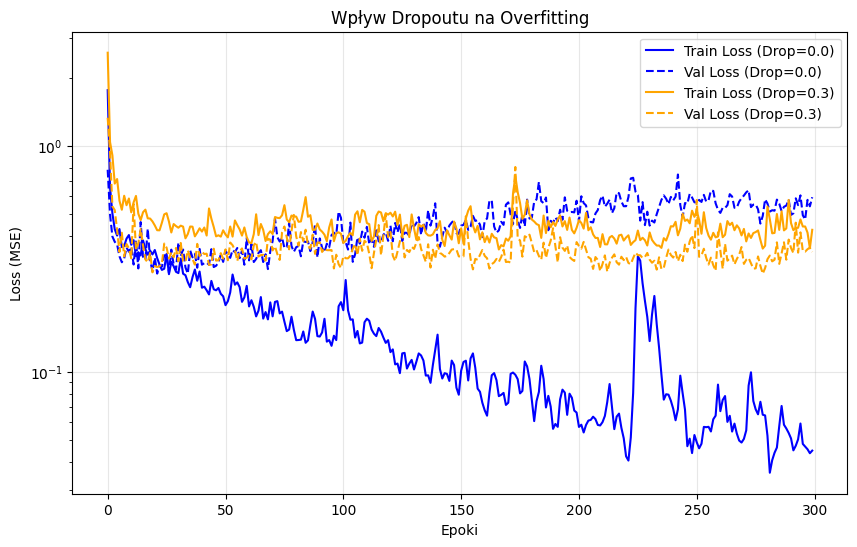

In [31]:
plt.figure(figsize=(10, 6))

hist_0 = histories['Głęboka [256, 256, 256] - 0'].history
hist_03 = histories['Głęboka [256, 256, 256] - 0.3'].history

plt.plot(hist_0['loss'], label='Train Loss (Drop=0.0)', color='blue', linestyle='-')
plt.plot(hist_0['val_loss'], label='Val Loss (Drop=0.0)', color='blue', linestyle='--')

plt.plot(hist_03['loss'], label='Train Loss (Drop=0.3)', color='orange', linestyle='-')
plt.plot(hist_03['val_loss'], label='Val Loss (Drop=0.3)', color='orange', linestyle='--')

plt.title("Wpływ Dropoutu na Overfitting")
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.yscale('log')  # Skala logarytmiczna uwydatnia różnice
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
# dropout skutecznie zapobiegl przeuczeniu, bez dropoutu widac ze model sie rozjechal

In [33]:
model_v4 = build_model(8, [16], 'relu', 0, 1, None)

history_v4 = train_model(model_v4, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 0, 0
    )

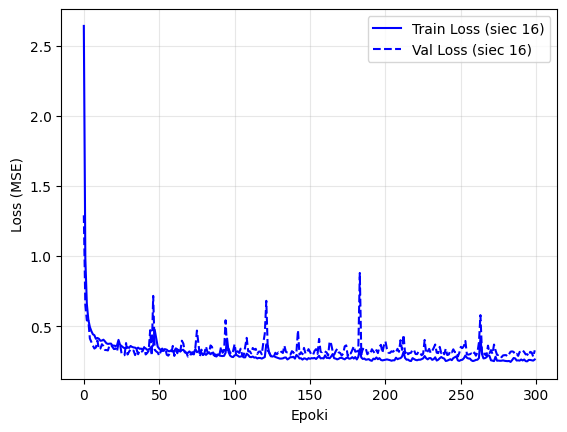

In [34]:
hist_16 = history_v4.history

plt.plot(hist_16['loss'], label='Train Loss (siec 16)', color='blue', linestyle='-')
plt.plot(hist_16['val_loss'], label='Val Loss (siec 16)', color='blue', linestyle='--')
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
# model z early stopping - duzy model

In [36]:
model_v5 = build_model(8, [256, 256, 256], 'relu', 0, 1, None)

history_v5 = train_model(
    model_v5, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 10, 0
    )


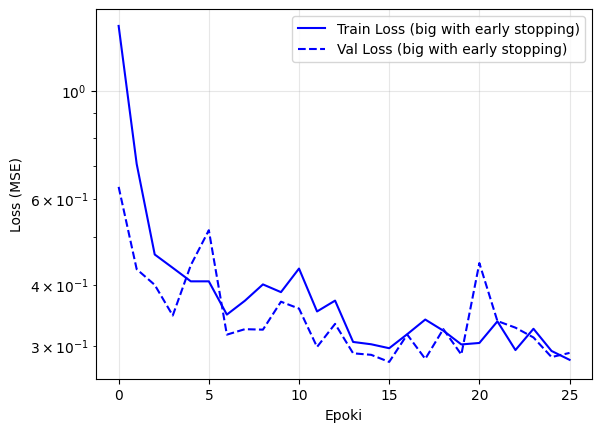

In [37]:
hist_es_big = history_v5.history

plt.plot(hist_es_big['loss'], label='Train Loss (big with early stopping)', color='blue', linestyle='-')
plt.plot(hist_es_big['val_loss'], label='Val Loss (big with early stopping)', color='blue', linestyle='--')
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.yscale('log')  # Skala logarytmiczna uwydatnia różnice
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# model z early stoping skutecznie zapobiegl overfitingowi

In [39]:
df_summary_v2

,Nazwa,Train Loss,Val Loss,Train MAE,Test Loss,Test MAE
0,"Głęboka [256, 256, 256] - 0",0.044714,0.591717,0.151586,0.586772,0.523498
1,"Głęboka [256, 256, 256] - 0.1",0.166213,0.282623,0.297179,0.461095,0.468352
2,"Głęboka [256, 256, 256] - 0.3",0.424476,0.338770,0.475887,0.448198,0.490620
3,"Głęboka [256, 256, 256] - 0.5",0.639848,0.510726,0.610658,0.591024,0.586898
4,"Głęboka [256, 256, 256] - 0.8",1.257305,1.067630,0.876017,1.331024,0.899090


In [40]:
# wyzsza wartosc train loss nad val loss mowi nam o dzialaniu dropoutu- 

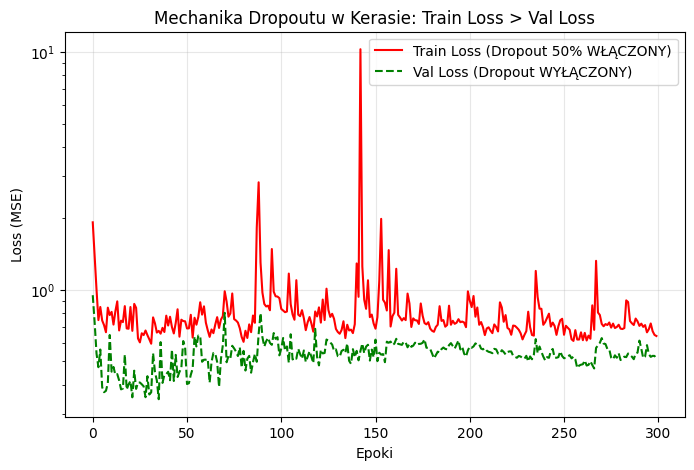

In [41]:
plt.figure(figsize=(8, 5))

# Pobranie danych z Twojego słownika
hist_05 = histories["Głęboka [256, 256, 256] - 0.5"].history
plt.plot(hist_05['loss'], label='Train Loss (Dropout 50% WŁĄCZONY)', color='red', linestyle='-')
plt.plot(hist_05['val_loss'], label='Val Loss (Dropout WYŁĄCZONY)', color='green', linestyle='--')

plt.title("Mechanika Dropoutu w Kerasie: Train Loss > Val Loss")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoki")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dropout - Mechanika i Interpretacja

* **Cel główny (Generalizacja):** Losowe wyłączanie neuronów zmusza sieć do szukania uniwersalnych wzorców. Zapobiega "wkuwaniu" danych na blachę (overfittingowi).
* **Dlaczego Train Loss > Val Loss?**
  * **Faza Treningu:** Dropout WŁĄCZONY. Sieć uczy się z uciętą mocą (np. -50% neuronów), co sztucznie winduje błąd w górę.
  * **Faza Walidacji (i Testu):** Dropout WYŁĄCZONY. Sieć odzyskuje 100% neuronów. Dzięki pełnej mocy obliczeniowej radzi sobie z danymi lepiej niż na treningu, dlatego błąd spada.

# dropout predict/evaluate vs fit 

* **`model.fit()` (`training=True`):**
  * **Dropout jest WŁĄCZONY.**
  * Losowo zeruje zadaną część neuronów w każdym kroku (np. 30% lub 50%).
  * **Cel:** Rozbicie współzależności między neuronami i zmuszenie sieci do nauki uniwersalnych cech (blokada overfittingu). Reszte neuronow model mnozy o wage odjetych np 1 1 1 1 dropout 0.5 to 1 1 0 0 i 1/1-0.5 = 2 i wyhcodzi 2 2 0 0

* **`model.predict()` oraz `evaluate()` (`training=False`):**
  * **Dropout jest WYŁĄCZONY.**
  * Wszystkie neurony działają na 100% swoich możliwości, bez zerowania wag.
  * **Cel:** Wykorzystanie pełnej pojemności wyuczonego modelu do stabilnych predykcji.

# zadanie 17

In [52]:
import seaborn as sns

In [53]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [54]:
import pandas as pd

def explore_titanic(df):
    summary = pd.DataFrame({
        'Type': df.dtypes,
        'Nan values': df.isna().sum(),
        'non values percent': (df.isna().mean() * 100).round(1),
    })
    
    print(f"Shape: {df.shape[0]} , {df.shape[1]} \n")
    display(summary)
    
    target_summary = pd.DataFrame({
        'Number': df['survived'].value_counts(),
        '(%)': (df['survived'].value_counts(normalize=True) * 100).round(1)
    })
    display(target_summary)

explore_titanic(titanic)

Shape: 891 , 15 



,Type,Nan values,non values percent
survived,int64,0,0.0
pclass,int64,0,0.0
sex,str,0,0.0
age,float64,177,19.9
sibsp,int64,0,0.0
parch,int64,0,0.0
fare,float64,0,0.0
embarked,str,2,0.2
class,category,0,0.0
who,str,0,0.0


,Number,(%)
survived,,
0,549,61.6
1,342,38.4


In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def prepare_titanic(df):
    
    feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

    X = df[feature_cols]
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

    
    num_cols = ['age', 'sibsp', 'parch', 'fare']
    cat_cols = ['pclass', 'sex', 'embarked']

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            drop='first',           # Usuwa pierwszą kolumnę (zapobiega współliniowości / dummy variable trap)
        sparse_output=False,    # Zwraca zwykłą tablicę NumPy zamiast macierzy rzadkiej (scipy.sparse)
        handle_unknown='ignore')) # Nie wysypuje błędu, gdy w teście pojawi się nowa, nieznana kategoria
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_processing', num_pipeline, num_cols),
            ('cat_processing', cat_pipeline, cat_cols)
    ])

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, preprocessor

X_train_scaled, X_test_scaled, y_train, y_test, preprocessor = prepare_titanic(titanic)

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
y_pred = logmodel.predict(X_test_scaled)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       165
           1       0.75      0.70      0.72       103

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



In [61]:
dummy = DummyClassifier(strategy='most_frequent')

dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)

In [62]:
print(classification_report(y_test, y_pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.62      1.00      0.76       165
           1       0.00      0.00      0.00       103

    accuracy                           0.62       268
   macro avg       0.31      0.50      0.38       268
weighted avg       0.38      0.62      0.47       268



In [63]:
# mediana jest bezpiecznym wyborem poniewaz nie bierze pod uwage outlinerow tak jak srednia. 
# parametr stratify y wymusza na tym zeby dane byly podzielone na tyle samo probek zbior treningowy i testowy
# dokladnosc modelu ktory mowi ze kazdy nie przezyl wynosi 0.62

# zadanie 18

In [64]:
from itertools import product

def run_titanic_experiment(depths, widths, activations, dropouts, X_train, y_train):
    
    histories = {}

    input_dim = X_train.shape[1]

    for dep, wid, act, drop in product(depths, widths, activations, dropouts):
        exp_name = f" depth_{dep}_width_{wid}_act_{act}_dropout_{drop}" 

    
        model = Sequential()
        model.add(layers.Input(shape=(input_dim,)))
        
        
        for _ in range(dep):
            model.add(layers.Dense(wid, activation=act))
            if drop > 0:
                model.add(layers.Dropout(drop))

        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.01),
        loss = 'binary_crossentropy',
        metrics = ['accuracy'])
                
        early_stop = EarlyStopping(
        monitor='val_loss',        # metryka do obserwacji
        patience=15,               # ile epok bez poprawy czekamy przed przerwaniem
        restore_best_weights=True  # cofa wagi do najlepszej epoki 
                )

        
        history = model.fit(
        X_train, 
        y_train, 
        validation_split=0.2, 
        verbose=0, 
        epochs=300,
        callbacks = [early_stop]
        )

        histories[exp_name] = history

    return histories

In [65]:
histories_v3 = run_titanic_experiment([16, 64], [1, 2, 3], ['relu', 'tanh'], [0.0, 0.3], X_train_scaled, y_train)
histories_v3

{' depth_16_width_1_act_relu_dropout_0.0': <keras.src.callbacks.history.History at 0x12618eb10>,
 ' depth_16_width_1_act_relu_dropout_0.3': <keras.src.callbacks.history.History at 0x123358770>,
 ' depth_16_width_1_act_tanh_dropout_0.0': <keras.src.callbacks.history.History at 0x1273b8830>,
 ' depth_16_width_1_act_tanh_dropout_0.3': <keras.src.callbacks.history.History at 0x127e60af0>,
 ' depth_16_width_2_act_relu_dropout_0.0': <keras.src.callbacks.history.History at 0x12869e030>,
 ' depth_16_width_2_act_relu_dropout_0.3': <keras.src.callbacks.history.History at 0x127df6d50>,
 ' depth_16_width_2_act_tanh_dropout_0.0': <keras.src.callbacks.history.History at 0x127df7550>,
 ' depth_16_width_2_act_tanh_dropout_0.3': <keras.src.callbacks.history.History at 0x12a511c70>,
 ' depth_16_width_3_act_relu_dropout_0.0': <keras.src.callbacks.history.History at 0x12afb5310>,
 ' depth_16_width_3_act_relu_dropout_0.3': <keras.src.callbacks.history.History at 0x12ba10c90>,
 ' depth_16_width_3_act_tanh_d

In [66]:
from sklearn.metrics import roc_auc_score


test_results = []

for name, h in histories_v3.items():
    loss, acc = h.model.evaluate(X_test_scaled, y_test, verbose=0)
    y_probs = h.model.predict(X_test_scaled, verbose=0)
    roc_auc = roc_auc_score(y_test, y_probs)
    test_results.append({
        "Konfiguracja": name,
        "Liczba parametrów": h.model.count_params(),     
        "Liczba epok": len(h.history['loss']),
        "Dokładność testowa": round(acc, 4),
        "loss": h.history['loss'][-1],
        "val_loss": h.history['val_loss'][-1],
        "val_acc": h.history['val_accuracy'][-1],
        "roc_auc": round(roc_auc, 4),
    })

df = pd.DataFrame(test_results)
df = df.sort_values(by= 'Dokładność testowa', ascending = False).reset_index(drop=True)

df
    

,Konfiguracja,Liczba parametrów,Liczba epok,Dokładność testowa,loss,val_loss,val_acc,roc_auc
0,depth_16_width_3_act_tanh_dropout_0.0,214,36,0.7836,0.505283,0.540389,0.768,0.8309
1,depth_16_width_2_act_tanh_dropout_0.0,113,34,0.7724,0.534798,0.560763,0.752,0.7841
2,depth_16_width_1_act_tanh_dropout_0.0,42,32,0.7425,0.511332,0.540388,0.760,0.7459
3,depth_16_width_1_act_relu_dropout_0.0,42,37,0.6157,0.671250,0.645750,0.664,0.5000
4,depth_64_width_1_act_tanh_dropout_0.0,138,32,0.6157,0.671345,0.647529,0.664,0.5000
5,depth_64_width_3_act_tanh_dropout_0.0,790,32,0.6157,0.671340,0.644844,0.664,0.5000
6,depth_64_width_3_act_relu_dropout_0.3,790,47,0.6157,0.671490,0.646046,0.664,0.5000
7,depth_64_width_3_act_relu_dropout_0.0,790,30,0.6157,0.671470,0.645162,0.664,0.5000
8,depth_64_width_2_act_tanh_dropout_0.3,401,37,0.6157,0.671586,0.644130,0.664,0.5000
9,depth_64_width_2_act_tanh_dropout_0.0,401,30,0.6157,0.672242,0.644206,0.664,0.5000


In [67]:
# roc auc mierzy zdolnosc modelu do rozrozniania klas - przezyl i nieprzezyl

In [72]:
best_model_tyt = histories_v3[' depth_16_width_3_act_tanh_dropout_0.0'].model
best_model_tyt

<Sequential name=sequential_13, built=True>

In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score

def evaluate_classifier(model, X_test, y_test):
    
    y_probs = best_model_tyt.predict(X_test_scaled)
    y_pred = (y_probs >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.show()

    return f" acc:{acc}, f1:{f1}"

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


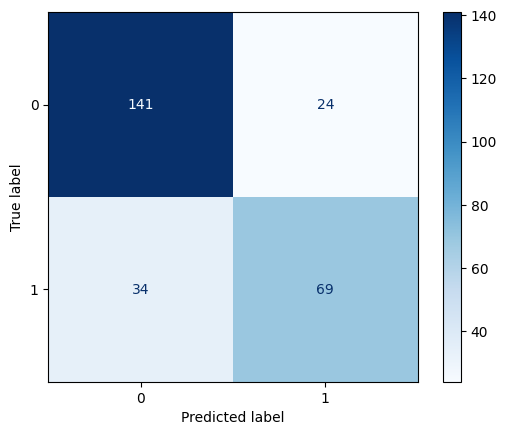

' acc:0.7835820895522388, f1:0.7040816326530612'

In [76]:
evaluate_classifier(best_model_tyt, X_test_scaled, y_test)

In [ ]:
def find_best_threshold(model, X, y):
    y_probs = model.predict(X, verbose=0)
    
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    scores = {}
    
    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        scores[round(t, 2)] = round(f1_score(y, y_pred), 4)
        
    best_t = max(scores, key=scores.get)
    print(f"Najlepszy próg: {best_t} (F1: {scores[best_t]})")
    
    return scores

        
find_best_threshold(best_model, X_test_scaled, y_test)       

In [ ]:
# 1. nie 2. zaszkodził - modele o dropout 0 były najlepsze . 3. roc auc jest sensowniejsza bo mówi nam ile procent model ma na odróżnianie obu klas, a nie całej dokładności .

# Accuracy ocenia trafność twardych decyzji (0 lub 1) przy jednym, sztywnym progu odcięcia, a ROC-AUC ocenia jakość samego prawdopodobieństwa i zdolność modelu do uszeregowania próbek na wszystkich możliwych progach jednocześnie.

# zadanie 19 

In [83]:
from sklearn.datasets import load_iris

X_iris, y_iris = load_iris(as_frame=True, return_X_y=True)

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled_iris = scaler.fit_transform(X_train)
X_test_scaled_iris = scaler.transform(X_test)

X_train_scaled_iris.shape

(105, 4)

In [88]:
seeds = [42, 1, 7, 99, 123]
scores_v1 = []


for s in seeds:

    keras.backend.clear_session()
    set_seed(s)
    
    Model_v1 = Sequential()
    Model_v1.add(layers.Input(shape=(4,)))
    Model_v1.add(layers.Dense(8, activation='relu'))
    Model_v1.add(layers.Dense(3, activation='softmax'))
    
    Model_v1.compile(
            optimizer = keras.optimizers.Adam(learning_rate=0.01),
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])
    
    history_v1 = Model_v1.fit(
            X_train_scaled_iris, 
            y_train_iris,
            validation_split=0.2,
            epochs=200,
            batch_size=16,
            verbose=0
        )

    y_pred = np.argmax(Model_v1.predict(X_test_scaled_iris, verbose=0), axis=1)
    acc = accuracy_score(y_test_iris, y_pred)
    scores_v1.append(acc)

mean_acc = np.mean(scores_v1)
std = np.std(scores_v1, ddof=1)

print(f"scores {scores_v1}, mean acc {mean_acc}, std {std}")

scores [0.9111111111111111, 0.9111111111111111, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111], mean acc 0.9155555555555555, std 0.00993807989999908


In [92]:
seeds = [42, 1, 7, 99, 123]
scores_v2 = []


for s in seeds:

    keras.backend.clear_session()
    set_seed(s)
    
    Model_v2 = Sequential()
    Model_v2.add(layers.Input(shape=(4,)))
    Model_v2.add(layers.Dense(128, activation='relu'))
    Model_v2.add(layers.Dense(128, activation='relu'))
    Model_v2.add(layers.Dense(3, activation='softmax'))
    
    Model_v2.compile(
            optimizer = keras.optimizers.Adam(learning_rate=0.01),
            loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])
    
    history_v2_best = Model_v2.fit(
            X_train_scaled_iris, 
            y_train_iris,
            validation_split=0.2,
            epochs=200,
            batch_size=16,
            verbose=0
        )

    y_pred_v2 = np.argmax(Model_v2.predict(X_test_scaled_iris, verbose=0), axis=1)
    acc = accuracy_score(y_test_iris, y_pred_v2)
    scores_v2.append(acc)

mean_acc_v2 = np.mean(scores_v2)
std_v2 = np.std(scores_v2, ddof=5)

history_v2_best
    
print(f"scores {scores_v2}, mean acc {mean_acc_v2}, std {std_v2}")

scores [0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9111111111111111, 0.9333333333333333], mean acc 0.9288888888888888, std inf


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: divide by zero encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [93]:
seeds = [42, 1, 7, 99, 123]
scores_v3 = []

for s in seeds:
    keras.backend.clear_session()  
    set_seed(s)

    Model_v3 = Sequential([
        layers.Input(shape=(4,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), 
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    
    Model_v3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    Model_v3.fit(
        X_train_scaled_iris, 
        y_train_iris,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0
    )

    y_pred_v3 = np.argmax(Model_v3.predict(X_test_scaled_iris, verbose=0), axis=1)
    scores_v3.append(accuracy_score(y_test_iris, y_pred_v3))

mean_acc_v3 = np.mean(scores_v3)
std_v3 = np.std(scores_v3, ddof=5)

print(f"scores: {[round(x, 4) for x in scores_v3]}")
print(f"mean acc: {mean_acc_v3:.4f}, std: {std_v3:.4f}")

scores: [0.8889, 0.9111, 0.9111, 0.9333, 0.9111]
mean acc: 0.9111, std: inf


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: divide by zero encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [91]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
seeds = [42, 1, 7, 99, 123]
rf_scores = []

for s in seeds:
    rfc = RandomForestClassifier(n_estimators=200, random_state = s)
    rfc.fit(X_train_scaled,y_train)

    y_pred = rfc.predict(X_test_scaled)
    rf_scores.append(accuracy_score(y_test, y_pred))

mean_rf = np.mean(rf_scores)
std_rf = np.std(rf_scores, ddof=1)

print(f"scores {rf_scores}, mean acc {mean_rf}, std {std_rf}")

scores [0.8888888888888888, 0.8888888888888888, 0.9111111111111111, 0.8888888888888888, 0.8888888888888888], mean acc 0.8933333333333333, std 0.00993807989999908


tak siec neuronowa jest dobrym sposobem zeby rozwiazac ten problem - acc na pziomie 93 proc

Odpowiedz: dlaczego dropout=0.5 przy tak małym zbiorze pogarsza wynik? Dlaczego odchylenie standardowe między ziarnami jest tu tak duże? Czy sieć neuronowa jest dla tego problemu dobrym wyborem?

# zadanie 20

In [ ]:
def benchmark_dataset(name, data, configs, seeds):

    for seed in seeds:
        

In [48]:
history_v1_ch

In [77]:
best_model_tyt

<Sequential name=sequential_13, built=True>

In [94]:
history_v2_best

{"small": ([16], 0.0), "medium": ([64, 32], 0.0), "medium_dropout": ([64, 32], 0.3), "large": ([256, 256], 0.0), "large_dropout": ([256, 256], 0.3)}.